In [30]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere,plot_error_map
import matplotlib.pyplot as plt

In [ ]:
def measure(circuit):
    temp_qc = circuit.copy()
    temp_qc.measure_all()
    display(temp_qc.draw('mpl'))
    
    backend = AerSimulator(method = 'automatic')
    result = backend.run(temp_qc,shots = 1024).result()
    counts = result.get_counts()
    print(counts)

In [11]:
def calculate_statevector(circuit):
    state_qc = circuit.copy()
    state_qc.save_statevector()
    backend = AerSimulator(method = 'statevector')
    psi = backend.run(state_qc,shots = 1024).result().get_statevector()
    print(psi)
    print("\nState vector as Bloch sphere:")
    display(plot_bloch_multivector(psi))
    print("\nState vector as Q sphere:")
    display(plot_state_qsphere(psi))
    measure(circuit)

In [20]:
def create_circuit(num_qubits):
    qc = QuantumCircuit(num_qubits)
    return qc

In [27]:
def main():
    print("Enter the number for circuits to explore!!!")
    inp = int(input("""\n0. Exit \n1 n-qubit visulization \n2. One qubit superposition\n3. 
                    Two qubit superposition\n4. Two qubit entanglement\n5. Multi qubit superposition"""))
    if inp == 0:
        pass
    elif inp == 1:
        ct = create_circuit(inp)
    elif inp == 2:
        ct = create_circuit(2)
        ct.h(0)
    elif inp == 3:
        ct = create_circuit(2)
        ct.h([0,1])
    elif inp == 4:
        ct = create_circuit(5)
        ct.h(0)
        ct.cx(0,1)
    elif inp == 5:
        num_qb = int(input("Enter the number of qubits:"))
        ct = create_circuit(num_qb)
        ct.h(range(num_qb))

        
    calculate_statevector(ct)

Enter the number for circuits to explore!!!
Statevector([0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j],
            dims=(2, 2))

State vector as Bloch sphere:


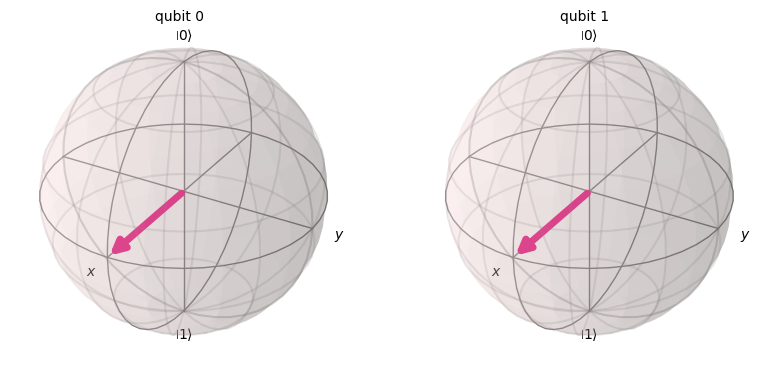


State vector as Q sphere:


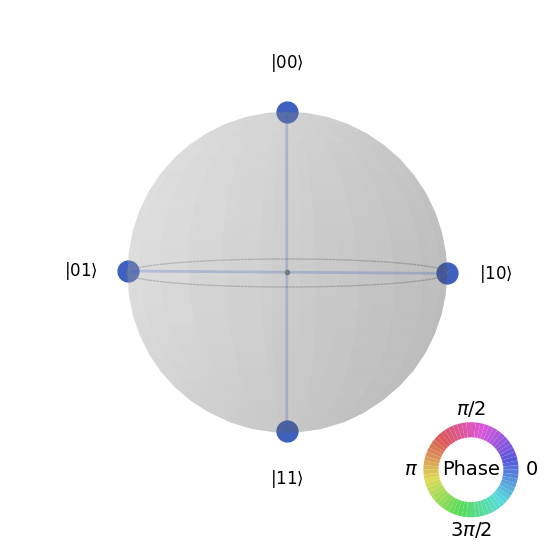

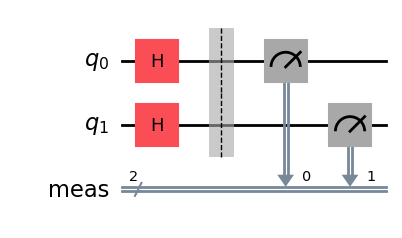

{'11': 244, '10': 258, '00': 248, '01': 274}


In [28]:
if __name__ == "__main__":
    main()